My first personal reaserch based on my knowledge in Data Science.

So, the idea of this research is to find out or predict my productivity rate, depending on data from "Flow" app (pomodoro timer).

I decided to make an excel file to store everything and to make tracking more careful.

In [1]:
import pandas as pd

file_path = "logs.xlsx"

df = pd.read_excel(file_path)

sessions = [i for i in pd.DataFrame(df)["sessions"]]
dates = [i for i in pd.DataFrame(df)["date"]]

print(sessions)
print(dates)


[4, 1, 3, 1, 12, 8, 12, 5, 7, 4, 13, 4, 7, 9, 11, 3, 8, 8, 1, 0, 8, 4, 3, 3, 8, 8, 4, 2, 6, 2, 2]
[Timestamp('2025-09-05 00:00:00'), Timestamp('2025-09-06 00:00:00'), Timestamp('2025-09-07 00:00:00'), Timestamp('2025-09-08 00:00:00'), Timestamp('2025-09-09 00:00:00'), Timestamp('2025-09-10 00:00:00'), Timestamp('2025-09-11 00:00:00'), Timestamp('2025-09-12 00:00:00'), Timestamp('2025-09-13 00:00:00'), Timestamp('2025-09-14 00:00:00'), Timestamp('2025-09-15 00:00:00'), Timestamp('2025-09-16 00:00:00'), Timestamp('2025-09-17 00:00:00'), Timestamp('2025-09-18 00:00:00'), Timestamp('2025-09-19 00:00:00'), Timestamp('2025-09-20 00:00:00'), Timestamp('2025-09-21 00:00:00'), Timestamp('2025-09-22 00:00:00'), Timestamp('2025-09-23 00:00:00'), Timestamp('2025-09-24 00:00:00'), Timestamp('2025-09-25 00:00:00'), Timestamp('2025-09-26 00:00:00'), Timestamp('2025-09-27 00:00:00'), Timestamp('2025-09-28 00:00:00'), Timestamp('2025-09-29 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-1

Now I have arrays with amount of sessions per day (sessions)

And also dates 

I will use dates a bit later:)

In [2]:
from statsmodels.tsa.arima.model import ARIMA


test_sessions = sessions[:15]


test_model_1 = ARIMA(test_sessions, order=(1,1,1))
# test_model_2 = ARIMA(test_sessions, order=(1,0,0))
# test_model_3 = ARIMA(test_sessions, order=(0,1,0))

fitted_1 = test_model_1.fit()
# fitted_2 = test_model_2.fit()
# fitted_3 = test_model_3.fit()

test_forecast_1 = fitted_1.forecast(steps = 2)
# test_forecast_2 = fitted_2.forecast(steps = 2)
# test_forecast_3 = fitted_3.forecast(steps = 2)

print(test_forecast_1)

model = ARIMA(sessions, order=(1,1,1))

fitted = model.fit()

forecast_1 = fitted.forecast(steps = 1)
forecast_5 = fitted.forecast(steps = 5)

print(forecast_1)
print(forecast_5)

[ 6.99802173 10.99995786]
[4.28060567]
[4.28060567 4.35475084 4.35716138 4.35723975 4.3572423 ]


What do we get here?

Actually nothing interesting, because we just predicted next number.

Can it be useful? Yes, now i know which order to use, based on test_model.

test_model showed that order (1,1,1) is more efficient

What's next? 

Let's try to use dates in research too

P.S. found interesting page about SARIMA model, i will try to use it:)

https://www.geeksforgeeks.org/machine-learning/sarima-seasonal-autoregressive-integrated-moving-average/


At this point I will again try to check different order, to understand how which one is more efficient

In [3]:
from statsmodels.tsa.api import SARIMAX

test_sessions = sessions[:15]

print(test_sessions)
print(sessions)
test_smodel_1 = SARIMAX(test_sessions, order=(1,0,0), seasonal_order=(0,0,0,7))
test_smodel_2 = SARIMAX(test_sessions, order=(0,1,0), seasonal_order=(0,0,0,7))
test_smodel_3 = SARIMAX(test_sessions, order=(1,1,1), seasonal_order=(0,0,0,7))

# results_1 = test_smodel_1.fit()
# results_2 = test_smodel_2.fit()
results_3 = test_smodel_3.fit()


# test_sforecast_1 = results_1.forecast(steps = 2)
# test_sforecast_2 = results_2.forecast(steps = 2)
test_sforecast_3 = results_3.forecast(steps = 2)


# print(test_sforecast_1)
# print(test_sforecast_2)
print(test_sforecast_3)




[4, 1, 3, 1, 12, 8, 12, 5, 7, 4, 13, 4, 7, 9, 11]
[4, 1, 3, 1, 12, 8, 12, 5, 7, 4, 13, 4, 7, 9, 11, 3, 8, 8, 1, 0, 8, 4, 3, 3, 8, 8, 4, 2, 6, 2, 2]
[ 6.99802173 10.99995786]


Okay, for now it's not too bad, because we got some good predictions. 

Let's draw a bit? 

What actually i want to see?

For now, just some graps from two models and their predictions



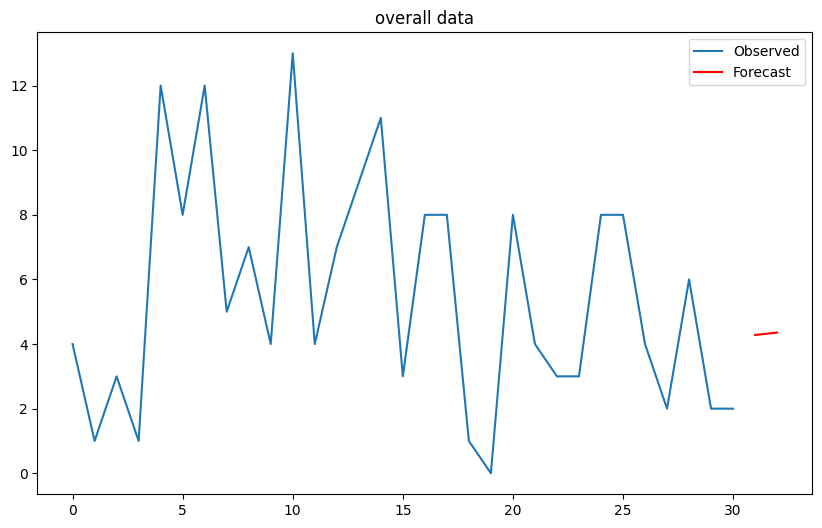

In [4]:
import matplotlib.pyplot as plt

# "ARIMA_test", "SARIMA_test", "actuall", "ARIMA_pred", "SARIMA_pred"

# ARIMA_test
# TODO: Make dates and add another model results
forecast_periods = 2

plt.figure(figsize=(10, 6))

forecast = fitted.forecast(steps=forecast_periods)

x_actual = range(len(sessions))
x_forecast = range(len(sessions), len(sessions) + forecast_periods)


plt.plot(x_actual, sessions, label='Observed')
plt.plot(x_forecast, forecast, label='Forecast', color='red')

plt.title('overall data')

plt.legend()
plt.show()